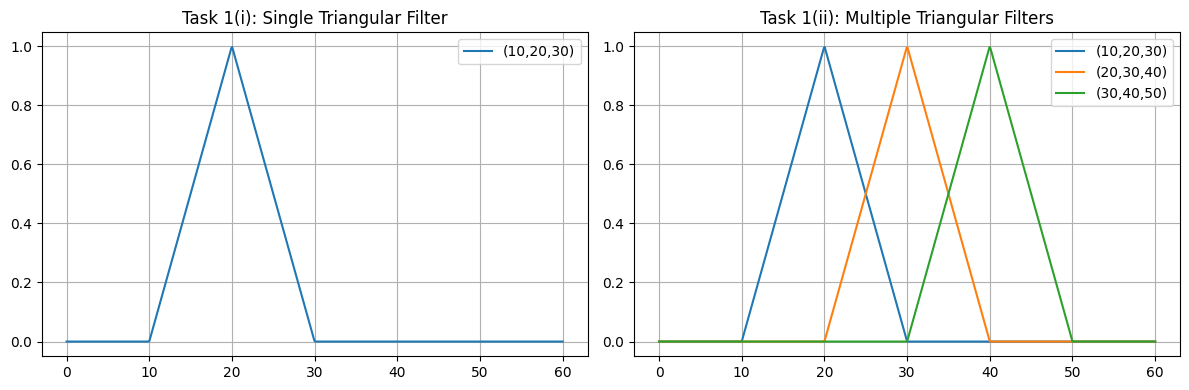

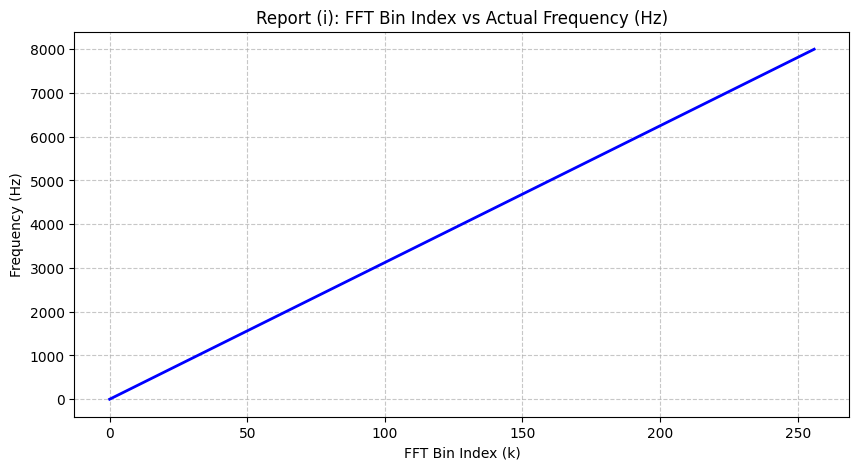

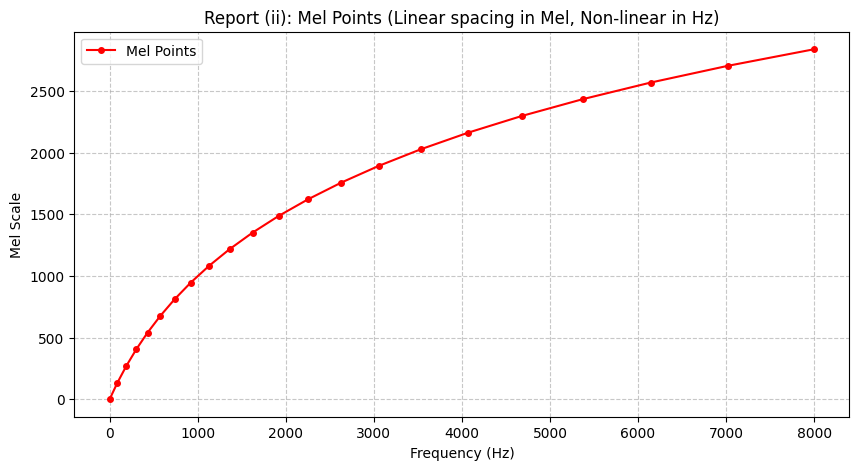

Filter #   | a (bin)  | b (bin)  | c (bin) 
----------------------------------------
Filter 1   | 0        | 2        | 6       
Filter 2   | 2        | 6        | 9       
Filter 3   | 6        | 9        | 13      
Filter 4   | 9        | 13       | 18      
Filter 5   | 13       | 18       | 23      
Filter 6   | 18       | 23       | 29      
Filter 7   | 23       | 29       | 36      
Filter 8   | 29       | 36       | 43      
Filter 9   | 36       | 43       | 52      
Filter 10  | 43       | 52       | 61      
Filter 11  | 52       | 61       | 72      
Filter 12  | 61       | 72       | 84      
Filter 13  | 72       | 84       | 97      
Filter 14  | 84       | 97       | 113     
Filter 15  | 97       | 113      | 130     
Filter 16  | 113      | 130      | 150     
Filter 17  | 130      | 150      | 172     
Filter 18  | 150      | 172      | 196     
Filter 19  | 172      | 196      | 224     
Filter 20  | 196      | 224      | 256     


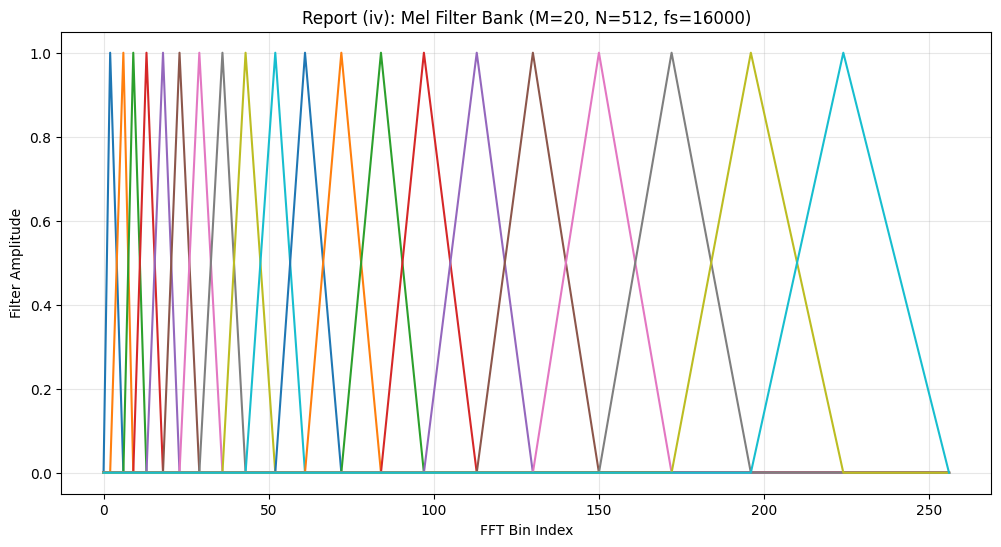

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def get_triangular_filter(k, a, b, c):
    """
    Constructs a single triangular filter based on points a, b, c.
    k: array of indices (e.g., FFT bins or samples)
    """
    h = np.zeros_like(k, dtype=float)


    mask_rising = (k >= a) & (k <= b)
    if b > a:
        h[mask_rising] = (k[mask_rising] - a) / (b - a)

    mask_falling = (k > b) & (k <= c)
    if c > b:
        h[mask_falling] = (c - k[mask_falling]) / (c - b)

    return h

k_range = np.linspace(0, 60, 600)

plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(k_range, get_triangular_filter(k_range, 10, 20, 30), label='(10,20,30)')
plt.title("Task 1(i): Single Triangular Filter")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
points = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]
for a, b, c in points:
    plt.plot(k_range, get_triangular_filter(k_range, a, b, c), label=f'({a},{b},{c})')
plt.title("Task 1(ii): Multiple Triangular Filters")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



fs = 16000
N = 512
M = 20
f_min = 0
f_max = fs / 2

def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)


mel_min = hz_to_mel(f_min)
mel_max = hz_to_mel(f_max)
mel_points = np.linspace(mel_min, mel_max, M + 2)

hz_points = mel_to_hz(mel_points)

bins = np.floor((N + 1) * hz_points / fs).astype(int)

bin_indices = np.arange(0, (N // 2) + 1)
actual_freqs = (bin_indices * fs) / N

plt.figure(figsize=(10, 5))
plt.plot(bin_indices, actual_freqs, 'b', linewidth=2)
plt.title("Report (i): FFT Bin Index vs Actual Frequency (Hz)")
plt.xlabel("FFT Bin Index (k)")
plt.ylabel("Frequency (Hz)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(hz_points, mel_points, 'ro-', markersize=4, label='Mel Points')
plt.title("Report (ii): Mel Points (Linear spacing in Mel, Non-linear in Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mel Scale")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"{'Filter #':<10} | {'a (bin)':<8} | {'b (bin)':<8} | {'c (bin)':<8}")
print("-" * 40)
for m in range(1, M + 1):
    print(f"Filter {m:<3} | {bins[m-1]:<8} | {bins[m]:<8} | {bins[m+1]:<8}")


plt.figure(figsize=(12, 6))
all_fft_bins = np.arange(0, (N // 2) + 1)

for m in range(1, M + 1):
    a, b, c = bins[m-1], bins[m], bins[m+1]

    h = get_triangular_filter(all_fft_bins, a, b, c)
    plt.plot(all_fft_bins, h)

plt.title(f"Report (iv): Mel Filter Bank (M={M}, N={N}, fs={fs})")
plt.xlabel("FFT Bin Index")
plt.ylabel("Filter Amplitude")
plt.grid(alpha=0.3)
plt.show()